In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv("DataONE_citations.csv")

# Preview
df.head()

,PID,Citation_text,Node_id,Node_name
0,10.5061/dryad.dk385,"Anatoly D. Erlykin, David A. T. Harper, Terry ...",urn:node:DRYAD,Dryad Digital Repository
1,10.5061/dryad.bn1gf,"Patrícia A Correia, Eran Lottem, Dhruba Banerj...",urn:node:DRYAD,Dryad Digital Repository
2,10.5061/dryad.320h5,"Timothy P. Topper, Luke C. Strotz, Christian B...",urn:node:DRYAD,Dryad Digital Repository
3,10.5061/dryad.8m2g3,"Robin A.A. Ince, Bruno L. Giordano, Christoph ...",urn:node:DRYAD,Dryad Digital Repository
4,10.5061/dryad.8b146,"Robin A.A. Ince, Bruno L. Giordano, Christoph ...",urn:node:DRYAD,Dryad Digital Repository


In [3]:
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   PID            1241 non-null   str  
 1   Citation_text  1241 non-null   str  
 2   Node_id        1240 non-null   str  
 3   Node_name      1240 non-null   str  
dtypes: str(4)
memory usage: 438.5 KB
None
                        PID  ...                 Node_name
count                  1241  ...                      1240
unique                  959  ...                         7
top     10.3334/CDIAC/00001  ...  Dryad Digital Repository
freq                     43  ...                       622

[4 rows x 4 columns]
PID              0
Citation_text    0
Node_id          1
Node_name        1
dtype: int64


In [5]:
df = df.bfill()

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

# Explicitly select string columns using 'string' dtype
for col in df.select_dtypes(include=['string', 'object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # ensure it's string
    label_encoders[col] = le

In [9]:
df.columns = df.columns.str.strip()

In [11]:
print("Columns:", df.columns.tolist())

Columns: ['PID', 'Citation_text', 'Node_id', 'Node_name']


In [13]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()
X = iris.data      # Features
y = iris.target    # Labels

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



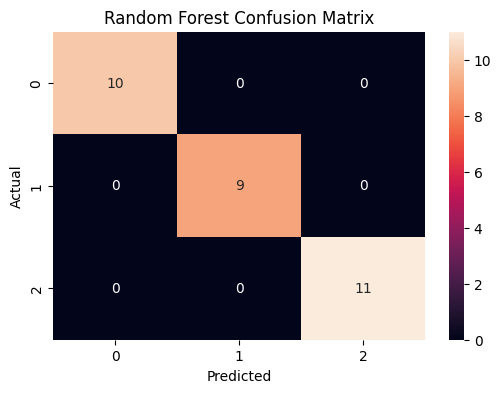

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()